In [2]:
# Imports and initializaion
import numpy as np
import matplotlib.pyplot as plt
import spe_loader as sl
import scipy as sp
import scipy.constants as sc
import glob
from scipy.stats import norm
import pandas as pd
from scipy.optimize import curve_fit
import sys
sys.path.append('..')
from spefile3 import *


# Dead dot

Successfully loaded 1 file(s) in a SpeFile object


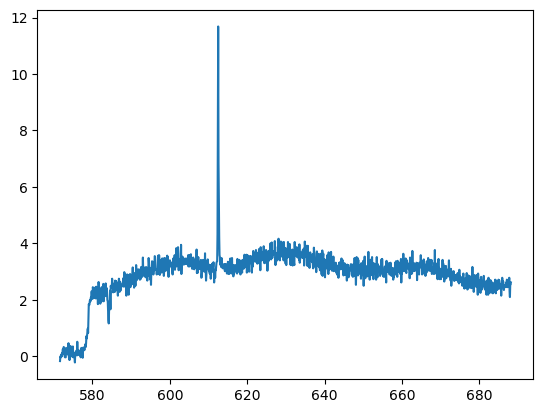

In [61]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_08_28/382_10uW_580LP_midcavity 2024 August 28 12_32_31.spe"
s = speFile3(filename)
frameNum = 0
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]/s.exposure
plt.plot(x_data, y_data)
df_deaddot = pd.DataFrame({'Wavelength (nm)': x_data, 'Intensity (counts/s)': y_data})
df_deaddot.to_csv('deaddot.csv', index=False)


# Empty cavity


Successfully loaded 1 file(s) in a SpeFile object


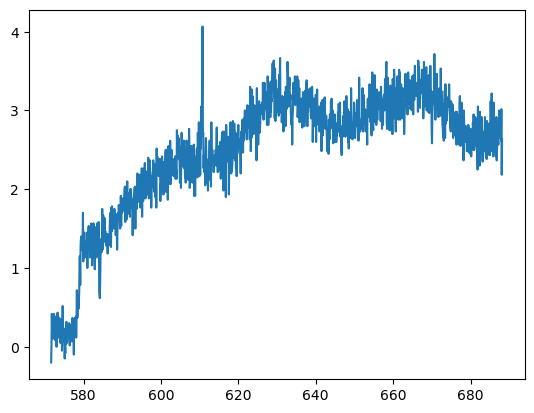

In [58]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_08_28/282_10uW_580LP_middlecavity 2024 August 28 12_10_39.spe"
s = speFile3(filename)
frameNum = 0
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]/s.exposure
plt.plot(x_data, y_data)
df_empty_cavity = pd.DataFrame({'Wavelength (nm)': x_data, 'Intensity (counts/s)': y_data})
df_empty_cavity.to_csv('emptycavity.csv', index=False)


Dot on bare SiO2 that I took some time ago of hao's doped B2 large shell

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Successfully loaded 1 file(s) in a SpeFile object


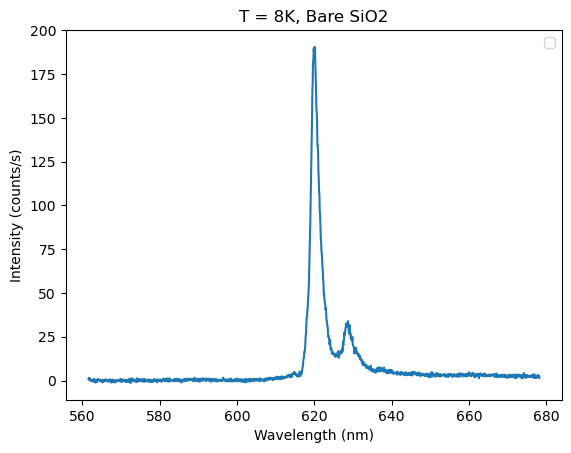

In [140]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_10_14/thickshell_mncdse_cds_lowT/1/1uW_CW_10 2024 October 14 09_42_25 40.spe"
s = speFile3(filename)
frameNum = 0
# Select data within the range from the beginning to 640 nm
mask = (s.wavelengths <= 680)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]

# Subtract the average of the first 100 points from y_data
average_first_100 = np.mean(y_data[:100])
y_data_bkg_subtracted = y_data - average_first_100
y_data = y_data_bkg_subtracted/s.exposure

# Plot the data
plt.plot(x_data, y_data)
df = pd.DataFrame({'x': x_data, 'y': y_data})
df.to_csv('lowT_nocavity.csv')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (counts/s)')
plt.title('T = 8K, Bare SiO2')
plt.legend()
plt.show()


Temp dependence

Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object


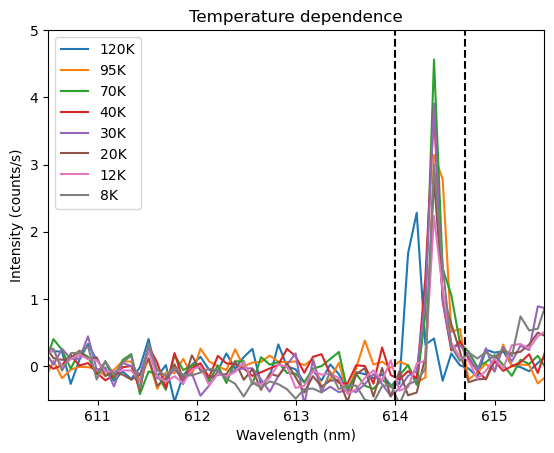

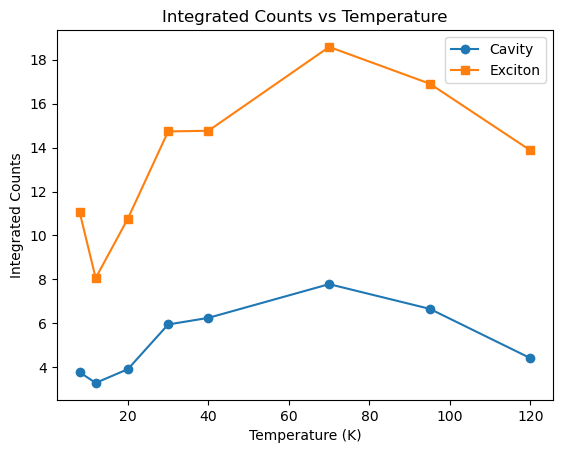

In [54]:
filenames = ["/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_120K 2024 December 05 17_54_06.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_95K 2024 December 05 17_26_32.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_70K 2024 December 05 17_07_54.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_40K 2024 December 05 16_48_31.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_30K 2024 December 05 16_41_23.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_20K 2024 December 05 16_27_30.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_12K 2024 December 05 16_10_33.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_10uW_60sec_615center_300groove 2024 December 05 15_42_34.spe"]
frameNum = 0
bkgfile = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/bkg_60sec_615center_300groove 2024 December 05 12_36_59.spe"
temps = [120, 95, 70, 40, 30, 20, 12, 8]
# Integrate the counts for each temperature from 614 to 614.6 nm (cavity mode)
cavity_mode_counts = []
exciton_mode_counts = []
for i in range(len(filenames)):
    # if i == 0: 
    #     s = speFile3(filenames[i])
    #     b = speFile3(bkgfile)
    #     s.data = np.array(s.data) - np.array(b.data)
    #     s.data = s.data - np.mean(s.data[0:100])
    # else:
    s = speFile3(filenames[i])
    s.data = np.array(s.data)/s.exposure
    #Select data within the range from the beginning to 640 nm
    mask = (s.wavelengths <= 640)
    x_data = s.wavelengths[mask]
    y_data = s.data[frameNum][0][0][mask]
    mask_linear = ((x_data >= 610) & (x_data <= 613.5)) | ((x_data >= 615) & (x_data <= 615.5))
    x_data_linear = x_data[mask_linear]
    y_data_linear = y_data[mask_linear]
    # Fit the data to a linear function
    def linear(x, m, c):
        return m * x + c

    popt_linear, _ = curve_fit(linear, x_data_linear, y_data_linear)

    # Subtract the linear fit from the data
    y_data_bkg_subtracted = y_data - linear(x_data, *popt_linear)
    plt.plot(x_data, y_data_bkg_subtracted, label = str(temps[i]) + 'K')
    plt.legend()
    plt.xlim([610.5,615.5])
    plt.ylim([-0.5,5])
    plt.ylabel('Intensity (counts/s)')
    plt.title('Temperature dependence')
    plt.xlabel('Wavelength (nm)')

    mask_cavity = (x_data >= 614) & (x_data <= 614.7)
    cavity_mode_counts.append(np.sum(y_data_bkg_subtracted[mask_cavity]))
    exciton_mode_counts.append(np.sum(linear(x_data, *popt_linear)[mask_cavity]))
plt.axvline(x=614.7, color = 'black', linestyle = '--')
plt.axvline(x=614, color = 'black', linestyle = '--')

# Plot the integrated counts as a function of temperature
plt.figure()
plt.plot(temps, cavity_mode_counts, 'o-', label='Cavity')
plt.plot(temps, exciton_mode_counts, 's-', label='Exciton')
plt.xlabel('Temperature (K)')
plt.ylabel('Integrated Counts')
plt.title('Integrated Counts vs Temperature')
plt.legend()
plt.show()




Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object


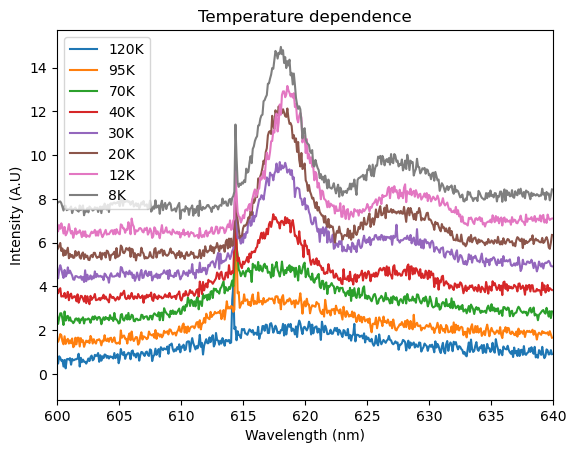

In [19]:
# need to run above plot before running this 
for i in range(len(filenames)):
    # if i == 0: 
    #     s = speFile3(filenames[i])
    #     b = speFile3(bkgfile)
    #     s.data = np.array(s.data) - np.array(b.data)
    #     s.data = s.data - np.mean(s.data[0:100])
    # else:
    s = speFile3(filenames[i])
    s.data = np.array(s.data)/s.exposure
    #Select data within the range from the beginning to 640 nm
    mask = (s.wavelengths <= 640)
    x_data = s.wavelengths[mask]
    y_data = s.data[frameNum][0][0][mask] + 1*i
    plt.plot(x_data, y_data, label = str(temps[i]) + 'K')
    plt.legend()
    plt.xlim([600,640])
    plt.ylabel('Intensity (A.U)')
    plt.title('Temperature dependence')
    plt.xlabel('Wavelength (nm)')

Low T power dependence for biexciton

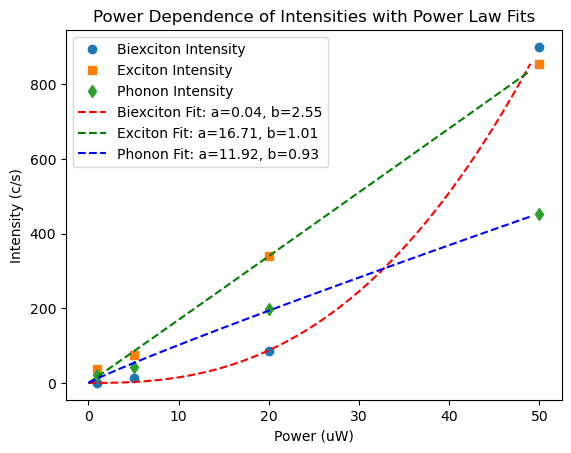

In [137]:
powers = [1,5,20,50]
ex = np.array([38.38, 75.88, 340.28, 853.39])
phonon = np.array([21.28, 43.82, 197.68, 453.25])
biex = np.array([0, 11.94, 86.60, 900.05])

#10 uW data
power10 = 10
biex10 = 124.49
ex10 = 376.58
phonon10 = 212.94

plt.plot(powers, biex, 'o', label='Biexciton Intensity')
#plt.plot(power10, biex10, 'o', label='Biexciton Intensity 10uW')
plt.plot(powers, ex, 's', label='Exciton Intensity')
#plt.plot(power10, ex10, 's', label='Exciton Intensity 10uW')
plt.plot(powers, phonon, 'd', label='Phonon Intensity')
#plt.plot(power10, phonon10, 'd', label='Phonon Intensity 10uW')
# Create a pandas dataframe
df_power_dependence = pd.DataFrame({'Power (uW)': powers, 'Biexciton Intensity': biex, 'Exciton Intensity': ex, 'Phonon Intensity': phonon})

# Save the dataframe to a CSV file
df_power_dependence.to_csv('power_dependence_data.csv', index=False)
# Define power law function
def power_law(x, a, b):
    return a * np.power(x, b)
powers_fit = np.arange(0, 50, 1)
# Fit and plot power law for biexciton intensity
popt_biex, _ = curve_fit(power_law, powers, biex)
plt.plot(powers_fit, power_law(powers_fit, *popt_biex), 'r--', label=f'Biexciton Fit: a={popt_biex[0]:.2f}, b={popt_biex[1]:.2f}')
# Fit and plot power law for exciton intensity
popt_ex, _ = curve_fit(power_law, powers, ex)
plt.plot(powers_fit, power_law(powers_fit, *popt_ex), 'g--', label=f'Exciton Fit: a={popt_ex[0]:.2f}, b={popt_ex[1]:.2f}')
# Fit and plot power law for phonon intensity
popt_phonon, _ = curve_fit(power_law, powers, phonon)
plt.plot(powers_fit, power_law(powers_fit, *popt_phonon), 'b--', label=f'Phonon Fit: a={popt_phonon[0]:.2f}, b={popt_phonon[1]:.2f}')

# Save powers_fit and the fitted biex, ex, and phonon fits to a CSV file
df_fits = pd.DataFrame({
    'Power (uW)': powers_fit,
    'Biexciton Fit': power_law(powers_fit, *popt_biex),
    'Exciton Fit': power_law(powers_fit, *popt_ex),
    'Phonon Fit': power_law(powers_fit, *popt_phonon)
})
df_fits.to_csv('power_law_fits.csv', index=False)
plt.xlabel('Power (uW)')
plt.ylabel('Intensity (c/s)')
plt.title('Power Dependence of Intensities with Power Law Fits')
plt.legend()
plt.show()

Successfully loaded 1 file(s) in a SpeFile object


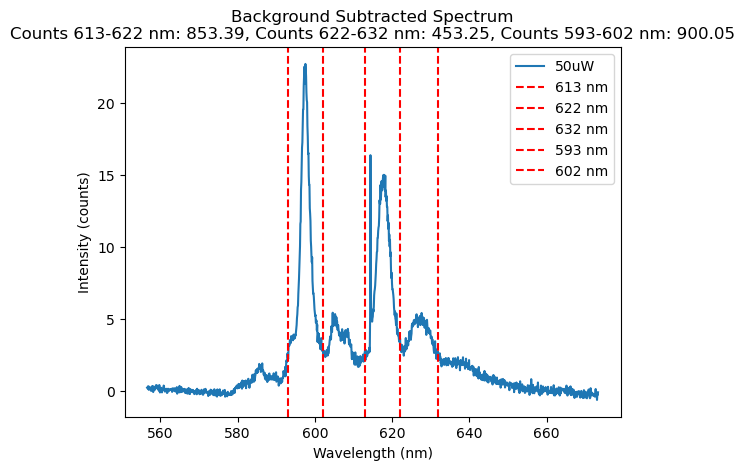

In [134]:
# 50uW 
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_50uW_60sec_615center_300groove 2024 December 05 15_38_19.spe"
s = speFile3(filename)
frameNum = 0
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]/60
mask_linear = ((x_data >= 560) & (x_data <= 580)) | ((x_data >= 655) & (x_data <= 670))
x_data_linear = x_data[mask_linear]
y_data_linear = y_data[mask_linear]
# Fit the data to a linear function
def linear(x, m, c):
    return m * x + c

popt_linear, _ = curve_fit(linear, x_data_linear, y_data_linear)

# Subtract the linear fit from the data
y_data_bkg_subtracted = y_data - linear(x_data, *popt_linear)
plt.plot(x_data, y_data_bkg_subtracted, label = '50uW')
# Add vertical lines and labels
plt.axvline(x=613, color='r', linestyle='--', label='613 nm')
plt.axvline(x=622, color='r', linestyle='--', label='622 nm')
plt.axvline(x=632, color='r', linestyle='--', label='632 nm')
plt.axvline(x=593, color='r', linestyle='--', label='593 nm')
plt.axvline(x=602, color='r', linestyle='--', label='602 nm')

# Integrate the counts in the specified ranges
range1_mask = (x_data >= 613) & (x_data <= 622)
range2_mask = (x_data >= 622) & (x_data <= 632)
range3_mask = (x_data >= 593) & (x_data <= 602)
range1_counts = np.sum(y_data_bkg_subtracted[range1_mask])
range2_counts = np.sum(y_data_bkg_subtracted[range2_mask])
range3_counts = np.sum(y_data_bkg_subtracted[range3_mask])

# Update the title to include the integrated counts
plt.title(f'Background Subtracted Spectrum\nCounts 613-622 nm: {range1_counts:.2f}, Counts 622-632 nm: {range2_counts:.2f}, Counts 593-602 nm: {range3_counts:.2f}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (counts)')
plt.legend()

Successfully loaded 1 file(s) in a SpeFile object


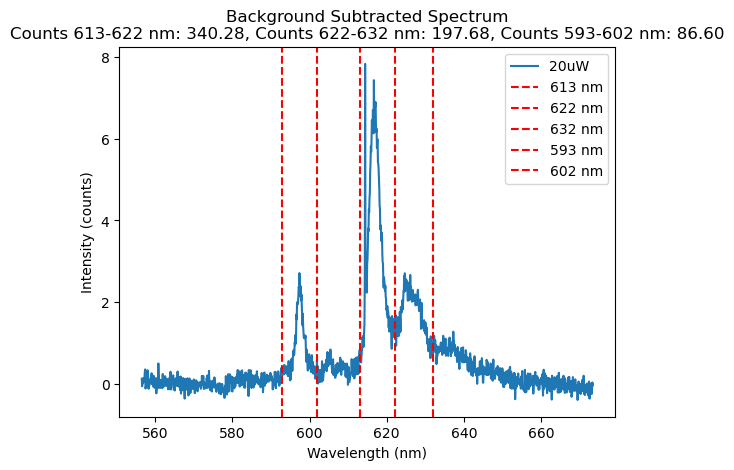

In [133]:
# 20uW 
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_20uW_60sec_615center_300groove 2024 December 05 15_34_05.spe"
s = speFile3(filename)
frameNum = 0
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]/60
mask_linear = ((x_data >= 560) & (x_data <= 580)) | ((x_data >= 655) & (x_data <= 670))
x_data_linear = x_data[mask_linear]
y_data_linear = y_data[mask_linear]
# Fit the data to a linear function
def linear(x, m, c):
    return m * x + c

popt_linear, _ = curve_fit(linear, x_data_linear, y_data_linear)

# Subtract the linear fit from the data
y_data_bkg_subtracted = y_data - linear(x_data, *popt_linear)
plt.plot(x_data, y_data_bkg_subtracted, label = '20uW')
# Add vertical lines and labels
plt.axvline(x=613, color='r', linestyle='--', label='613 nm')
plt.axvline(x=622, color='r', linestyle='--', label='622 nm')
plt.axvline(x=632, color='r', linestyle='--', label='632 nm')
plt.axvline(x=593, color='r', linestyle='--', label='593 nm')
plt.axvline(x=602, color='r', linestyle='--', label='602 nm')

# Integrate the counts in the specified ranges
range1_mask = (x_data >= 613) & (x_data <= 622)
range2_mask = (x_data >= 622) & (x_data <= 632)
range3_mask = (x_data >= 593) & (x_data <= 602)
range1_counts = np.sum(y_data_bkg_subtracted[range1_mask])
range2_counts = np.sum(y_data_bkg_subtracted[range2_mask])
range3_counts = np.sum(y_data_bkg_subtracted[range3_mask])

# Update the title to include the integrated counts
plt.title(f'Background Subtracted Spectrum\nCounts 613-622 nm: {range1_counts:.2f}, Counts 622-632 nm: {range2_counts:.2f}, Counts 593-602 nm: {range3_counts:.2f}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (counts)')
plt.legend()

Successfully loaded 1 file(s) in a SpeFile object


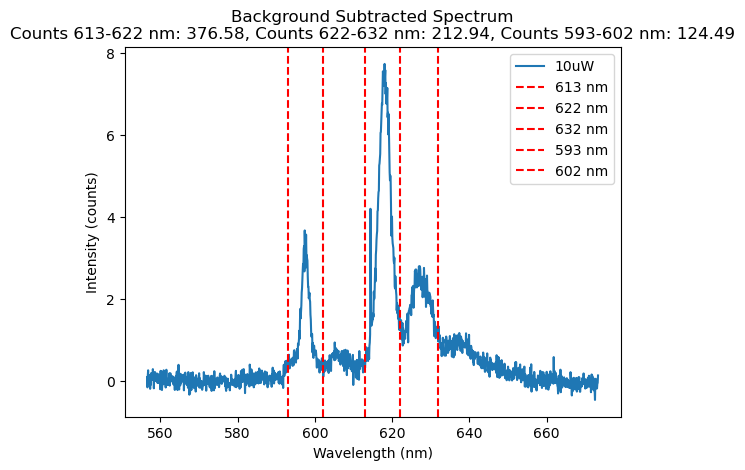

In [132]:
# 10uW 
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_10uW_60sec_615center_300groove 2024 December 05 15_42_34.spe"
s = speFile3(filename)
frameNum = 0
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]/60
mask_linear = ((x_data >= 560) & (x_data <= 580)) | ((x_data >= 655) & (x_data <= 670))
x_data_linear = x_data[mask_linear]
y_data_linear = y_data[mask_linear]
# Fit the data to a linear function
def linear(x, m, c):
    return m * x + c

popt_linear, _ = curve_fit(linear, x_data_linear, y_data_linear)

# Subtract the linear fit from the data
y_data_bkg_subtracted = y_data - linear(x_data, *popt_linear)
plt.plot(x_data, y_data_bkg_subtracted, label = '10uW')
# Add vertical lines and labels
plt.axvline(x=613, color='r', linestyle='--', label='613 nm')
plt.axvline(x=622, color='r', linestyle='--', label='622 nm')
plt.axvline(x=632, color='r', linestyle='--', label='632 nm')
plt.axvline(x=593, color='r', linestyle='--', label='593 nm')
plt.axvline(x=602, color='r', linestyle='--', label='602 nm')

# Integrate the counts in the specified ranges
range1_mask = (x_data >= 613) & (x_data <= 622)
range2_mask = (x_data >= 622) & (x_data <= 632)
range3_mask = (x_data >= 593) & (x_data <= 602)
range1_counts = np.sum(y_data_bkg_subtracted[range1_mask])
range2_counts = np.sum(y_data_bkg_subtracted[range2_mask])
range3_counts = np.sum(y_data_bkg_subtracted[range3_mask])

# Update the title to include the integrated counts
plt.title(f'Background Subtracted Spectrum\nCounts 613-622 nm: {range1_counts:.2f}, Counts 622-632 nm: {range2_counts:.2f}, Counts 593-602 nm: {range3_counts:.2f}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (counts)')
plt.legend()

Successfully loaded 1 file(s) in a SpeFile object


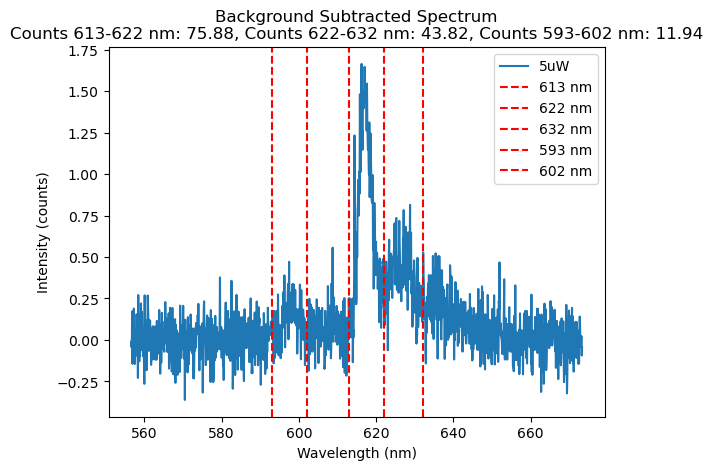

In [131]:
# 5uW 
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_5uW_60sec_615center_300groove 2024 December 05 15_07_29.spe"
s = speFile3(filename)
frameNum = 0
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]/60
mask_linear = ((x_data >= 560) & (x_data <= 580)) | ((x_data >= 655) & (x_data <= 670))
x_data_linear = x_data[mask_linear]
y_data_linear = y_data[mask_linear]
# Fit the data to a linear function
def linear(x, m, c):
    return m * x + c

popt_linear, _ = curve_fit(linear, x_data_linear, y_data_linear)

# Subtract the linear fit from the data
y_data_bkg_subtracted = y_data - linear(x_data, *popt_linear)
plt.plot(x_data, y_data_bkg_subtracted, label = '5uW')
# Add vertical lines and labels
plt.axvline(x=613, color='r', linestyle='--', label='613 nm')
plt.axvline(x=622, color='r', linestyle='--', label='622 nm')
plt.axvline(x=632, color='r', linestyle='--', label='632 nm')
plt.axvline(x=593, color='r', linestyle='--', label='593 nm')
plt.axvline(x=602, color='r', linestyle='--', label='602 nm')

# Integrate the counts in the specified ranges
range1_mask = (x_data >= 613) & (x_data <= 622)
range2_mask = (x_data >= 622) & (x_data <= 632)
range3_mask = (x_data >= 593) & (x_data <= 602)
range1_counts = np.sum(y_data_bkg_subtracted[range1_mask])
range2_counts = np.sum(y_data_bkg_subtracted[range2_mask])
range3_counts = np.sum(y_data_bkg_subtracted[range3_mask])

# Update the title to include the integrated counts
plt.title(f'Background Subtracted Spectrum\nCounts 613-622 nm: {range1_counts:.2f}, Counts 622-632 nm: {range2_counts:.2f}, Counts 593-602 nm: {range3_counts:.2f}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (counts)')
plt.legend()

Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object


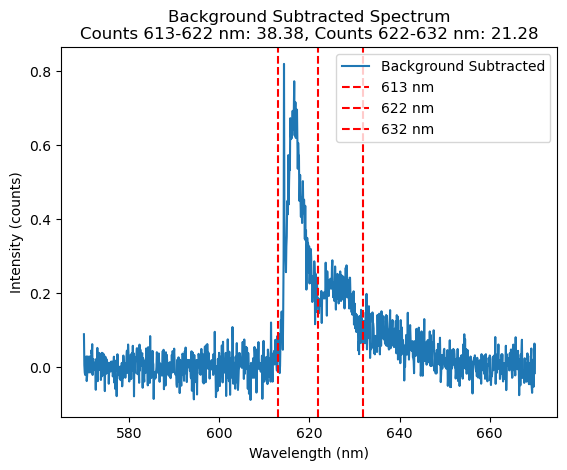

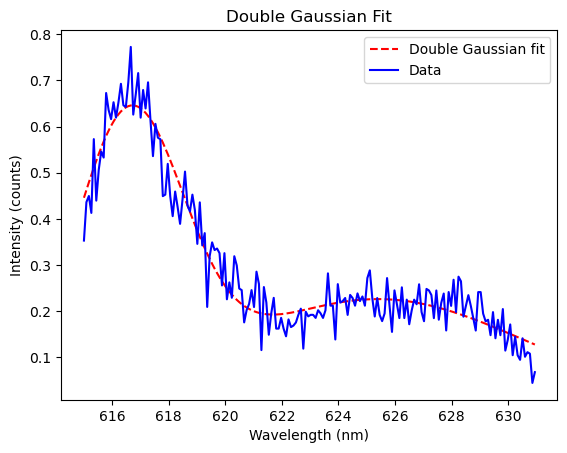

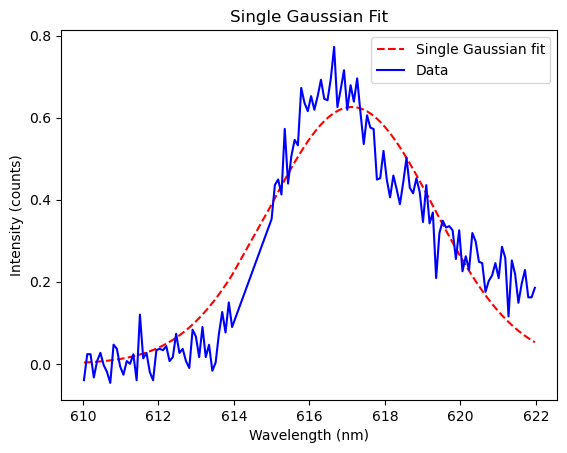

In [130]:
# 1uW
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_1uW_300sec_615center_300groove 2024 December 05 15_21_02.spe"
bkgfile = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/bkg_60sec_615center_300groove 2024 December 05 12_36_59.spe"

s = speFile3(filename)
b = speFile3(bkgfile)
s.data = np.array(s.data) - np.array(b.data)
mask = (s.wavelengths <= 670) & (s.wavelengths >= 570)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]/300
# Fit a linear line for data ranging from 570 to 600 nm and 655 to 670 nm
mask_linear = ((x_data >= 570) & (x_data <= 600)) | ((x_data >= 655) & (x_data <= 670))
x_data_linear = x_data[mask_linear]
y_data_linear = y_data[mask_linear]

# Fit the data to a linear function
def linear(x, m, c):
    return m * x + c

popt_linear, _ = curve_fit(linear, x_data_linear, y_data_linear)

# Subtract the linear fit from the data
y_data_bkg_subtracted = y_data - linear(x_data, *popt_linear)
maxs = np.argmax(y_data_bkg_subtracted)
# Set the maximum value and its neighbors to 0
y_data_bkg_subtracted[maxs-1:maxs+2] = 0
# Plot the result
plt.plot(x_data, y_data_bkg_subtracted, label='Background Subtracted')
# Integrate the counts in the specified ranges
range1_mask = (x_data >= 613) & (x_data <= 622)
range2_mask = (x_data >= 622) & (x_data <= 632)
range1_counts = np.sum(y_data_bkg_subtracted[range1_mask])
range2_counts = np.sum(y_data_bkg_subtracted[range2_mask])

# Add vertical lines and labels
plt.axvline(x=613, color='r', linestyle='--', label='613 nm')
plt.axvline(x=622, color='r', linestyle='--', label='622 nm')
plt.axvline(x=632, color='r', linestyle='--', label='632 nm')

# Update the title to include the integrated counts
plt.title(f'Background Subtracted Spectrum\nCounts 613-622 nm: {range1_counts:.2f}, Counts 622-632 nm: {range2_counts:.2f}')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (counts)')
#plt.ylim([0,300])
#plt.title('Background Subtracted Spectrum')
plt.legend()
plt.show()
# Define a function for the sum of two Gaussians
def double_gaussian(x, mu1, sigma1, a1, mu2, sigma2, a2):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))

# Select data within the range 615 to 631 nm
mask_double_gaussian = (x_data >= 615) & (x_data <= 631)
x_data_double_gaussian = x_data[mask_double_gaussian]
y_data_double_gaussian = y_data_bkg_subtracted[mask_double_gaussian]

# Fit the data to the double Gaussian function
popt_double_gaussian, _ = curve_fit(double_gaussian, x_data_double_gaussian, y_data_double_gaussian, p0=[617, 1, np.max(y_data_double_gaussian), 627, 10, np.max(y_data_double_gaussian)/4])

# Plot the fitted curve
y_fit_double_gaussian = double_gaussian(x_data_double_gaussian, *popt_double_gaussian)
plt.figure()
plt.plot(x_data_double_gaussian, y_fit_double_gaussian, 'r--', label='Double Gaussian fit')
plt.plot(x_data_double_gaussian, y_data_double_gaussian, 'b-', label='Data')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (counts)')
plt.title('Double Gaussian Fit')
plt.legend()
plt.show()
# Select data within the range 615 to 622 nm
mask_single_gaussian = ((x_data >= 610) & (x_data <= 614)) | ((x_data >= 615) & (x_data <= 622))
x_data_single_gaussian = x_data[mask_single_gaussian]
y_data_single_gaussian = y_data_bkg_subtracted[mask_single_gaussian]

# Define Gaussian function
def gaussian(x, mu, sigma, a):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit the data to the Gaussian function
popt_single_gaussian, _ = curve_fit(gaussian, x_data_single_gaussian, y_data_single_gaussian, p0=[618, 1, np.max(y_data_single_gaussian)])

# Plot the fitted curve
y_fit_single_gaussian = gaussian(x_data_single_gaussian, *popt_single_gaussian)
plt.figure()
plt.plot(x_data_single_gaussian, y_fit_single_gaussian, 'r--', label='Single Gaussian fit')
plt.plot(x_data_single_gaussian, y_data_single_gaussian, 'b-', label='Data')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (counts)')
plt.title('Single Gaussian Fit')
plt.legend()
plt.show()

# 615 to 622
# 622 to 631

Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Error - curve_fit failed
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Biexciton intensity:  [0, 0.23469768724069592, 1.9635439302229898, 19.85532295363874]
Exciton intensity:  [0.5769455116871194, 1.479661035216101, 6.405734266471293, 14.155122629596898]
Phonon intensity:  [0.16332821695273528, 0.6046971891157438, 2.658878849762724, 5.98679141003131]


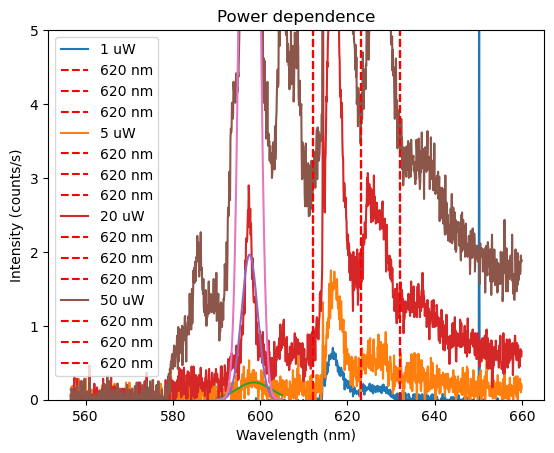

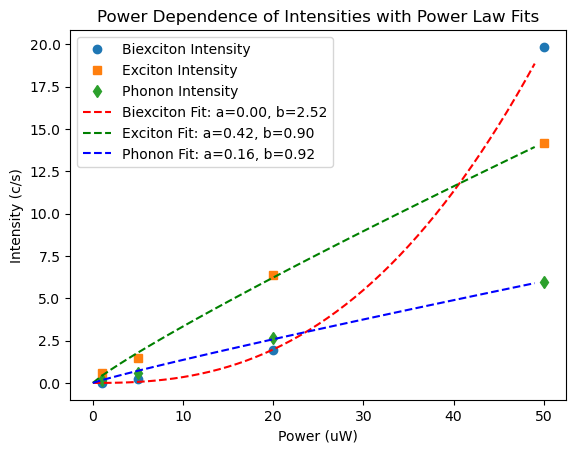

In [106]:
# Power dependence
filenames = ["/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_20uW_60sec_615center_300groove 2024 December 05 15_34_05.spe",
"/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_50uW_60sec_615center_300groove 2024 December 05 15_38_19.spe",
"/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_5uW_60sec_615center_300groove 2024 December 05 15_07_29.spe",
"/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_1uW_300sec_615center_300groove 2024 December 05 15_21_02.spe"]
frameNum = 0
bkgfile = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/bkg_60sec_615center_300groove 2024 December 05 12_36_59.spe"
powers = [20,50,5,1] # in uW
biex_intensity = []
ex_intensity = []
phonon_intensity = []   
# Sort powers and filenames in ascending order by powers
sorted_indices = sorted(range(len(powers)), key=lambda k: powers[k])
powers = [powers[i] for i in sorted_indices]
filenames = [filenames[i] for i in sorted_indices]
for i in range(len(filenames)):
    if i == 0: # 1uW file is 300 sec long and not bkg subtracted
        s = speFile3(filenames[i])
        b = speFile3(bkgfile)
        s.data = np.array(s.data) - np.array(b.data)
        s.data = s.data - np.mean(s.data[0:100])
    else:
        s = speFile3(filenames[i])
    s.data = np.array(s.data)/s.exposure
    # Select data within the range from the beginning to 640 nm
    mask = (s.wavelengths <= 660)
    x_data = s.wavelengths[mask]
    y_data = s.data[frameNum][0][0][mask]
    plt.plot(x_data, y_data, label = str(powers[i]) + ' uW')
    plt.axvline(x=623, color='r', linestyle='--', label='620 nm')
    plt.axvline(x=612, color='r', linestyle='--', label='620 nm')
    plt.axvline(x=632, color='r', linestyle='--', label='620 nm')

    plt.legend()
    plt.ylabel('Intensity (counts/s)')
    plt.title('Power dependence')
    plt.xlabel('Wavelength (nm)')

    # fit 595 peak
    # Select data within the range 590 to 600 nm
    mask_gaussian = (s.wavelengths >= 590) & (s.wavelengths <= 605)
    x_data_gaussian = s.wavelengths[mask_gaussian]
    y_data_gaussian = s.data[frameNum][0][0][mask_gaussian]

    # Define Gaussian function
    def gaussian(x, mu, sigma, a):
        return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # Fit the data to the Gaussian function
    try:
        popt_gaussian, _ = curve_fit(gaussian, x_data_gaussian, y_data_gaussian, p0=[595, 1, np.max(y_data_gaussian)])
        biex_intensity.append(popt_gaussian[2])
        plt.plot(x_data_gaussian, gaussian(x_data_gaussian, *popt_gaussian))
        plt.ylim([0,5])
    except RuntimeError:
        print('Error - curve_fit failed')
        popt_gaussian = [0, 0, 0]
        biex_intensity.append(0)


    # fit 615 peak
    # Select data within the range 590 to 600 nm
    mask_gaussian = (s.wavelengths >= 610) & (s.wavelengths <= 622)
    x_data_gaussian = s.wavelengths[mask_gaussian]
    y_data_gaussian = s.data[frameNum][0][0][mask_gaussian]
    try:
        popt_gaussian, _ = curve_fit(gaussian, x_data_gaussian, y_data_gaussian, p0=[617, 1, np.max(y_data_gaussian)])
        ex_intensity.append(popt_gaussian[2])
    except RuntimeError:
        print('Error - curve_fit failed')
        ex_intensity.append(0)


    # fit 625 peak phonon sideband peak
    # Select data within the range 590 to 600 nm
    mask_gaussian = (s.wavelengths >= 622) & (s.wavelengths <= 632)
    x_data_gaussian = s.wavelengths[mask_gaussian]
    y_data_gaussian = s.data[frameNum][0][0][mask_gaussian]
    try:
        popt_gaussian, _ = curve_fit(gaussian, x_data_gaussian, y_data_gaussian, p0=[627, 1, np.max(y_data_gaussian)])
        #plt.plot(x_data_gaussian, gaussian(x_data_gaussian, *popt_gaussian))
        phonon_intensity.append(popt_gaussian[2])
        #print(popt_gaussian)
    except RuntimeError:
        print('Error - curve_fit failed')
        phonon_intensity.append(0)

print('Biexciton intensity: ', biex_intensity) 
print('Exciton intensity: ', ex_intensity)
print('Phonon intensity: ', phonon_intensity)
df = pd.DataFrame({'powers':powers, 'biex': biex_intensity, 'ex': ex_intensity, 'phonon': phonon_intensity})
df.to_csv('power_dependence.csv')

plt.figure()
plt.plot(powers, biex_intensity, 'o', label='Biexciton Intensity')
plt.plot(powers, ex_intensity, 's', label='Exciton Intensity')
plt.plot(powers, phonon_intensity, 'd', label='Phonon Intensity')
plt.xlabel('Power (uW)')
plt.ylabel('Intensity (c/s)')
plt.title('Power Dependence of Intensities')
plt.legend()
# Define power law function
def power_law(x, a, b):
    return a * np.power(x, b)
powers_fit = np.arange(0, 50, 1)
# Fit and plot power law for biexciton intensity
popt_biex, _ = curve_fit(power_law, powers, biex_intensity)
plt.plot(powers_fit, power_law(powers_fit, *popt_biex), 'r--', label=f'Biexciton Fit: a={popt_biex[0]:.2f}, b={popt_biex[1]:.2f}')
df = pd.DataFrame({'x': powers_fit, 'y': power_law(powers_fit, *popt_biex)})
# Fit and plot power law for exciton intensity
popt_ex, _ = curve_fit(power_law, powers, ex_intensity)
plt.plot(powers_fit, power_law(powers_fit, *popt_ex), 'g--', label=f'Exciton Fit: a={popt_ex[0]:.2f}, b={popt_ex[1]:.2f}')
df = pd.DataFrame({'x': powers_fit, 'y': power_law(powers_fit, *popt_ex)})
# Fit and plot power law for phonon intensity
popt_phonon, _ = curve_fit(power_law, powers, phonon_intensity)
plt.plot(powers_fit, power_law(powers_fit, *popt_phonon), 'b--', label=f'Phonon Fit: a={popt_phonon[0]:.2f}, b={popt_phonon[1]:.2f}')
plt.xlabel('Power (uW)')
plt.ylabel('Intensity (c/s)')
plt.title('Power Dependence of Intensities with Power Law Fits')
plt.legend()
plt.show()


Low T cavity data

Successfully loaded 1 file(s) in a SpeFile object


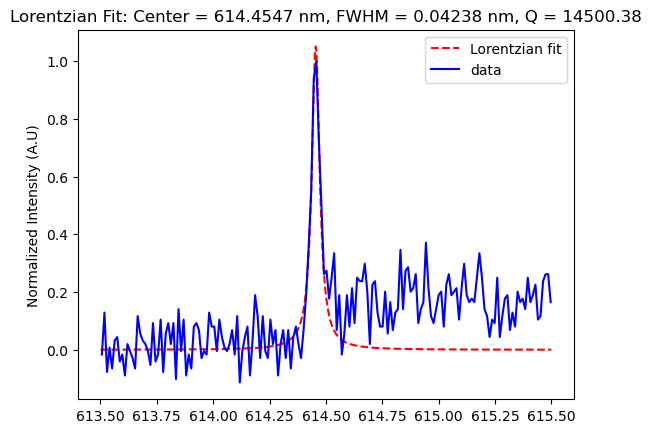

In [43]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/482_10uW_100sec_615center_1800groove 2024 December 05 14_53_24.spe"
s = speFile3(filename)
frameNum = 0
#s.quickPlot(frame = frameNum, ylim= None)
# Select data within the range 613 to 615 nm
mask = (s.wavelengths >= 613.5) & (s.wavelengths <= 614.5)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]
# Take average of first 20 points
average_first_20 = np.mean(y_data[:20])

# Subtract the average from y_data
y_data_bkg_subtracted = y_data - average_first_20
# Normalize y_data_bkg_subtracted
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))

# Fit the data to the Lorentzian function
popt, _ = curve_fit(lorentzian, x_data, y_data_normalized, p0=[614, 0.02, 1])

# Plot the fitted curve
x_fit = np.linspace(613.5, 615.5, 1000)
y_fit = lorentzian(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Lorentzian fit')

mask2 = (s.wavelengths >= 613.5) & (s.wavelengths <= 615.5)
x_data = s.wavelengths[mask2]
y_data = s.data[frameNum][0][0][mask2]
y_data_bkg_subtracted = y_data - average_first_20
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))
plt.plot(x_data, y_data_normalized, 'b-', label='data')
plt.ylabel('Normalized Intensity (A.U)')
plt.legend()
plt.title(f"Lorentzian Fit: Center = {popt[0]:.4f} nm, FWHM = {popt[1]:.5f} nm, Q = {popt[0]/popt[1]:.2f}")
plt.show()

Successfully loaded 1 file(s) in a SpeFile object


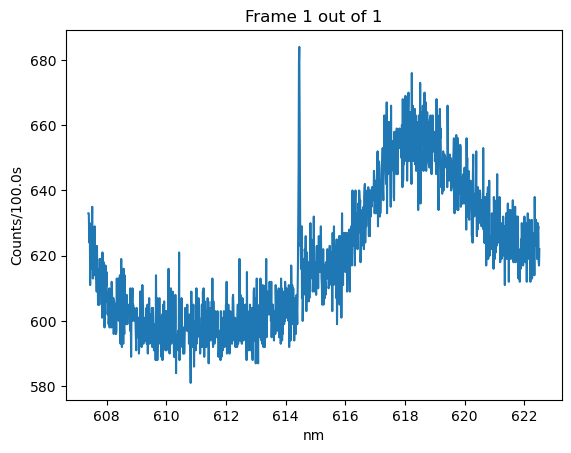

In [48]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/482_10uW_100sec_615center_1800groove 2024 December 05 14_53_24.spe"
s = speFile3(filename)
frameNum = 0
s.quickPlot(frame = frameNum, ylim= None)

Low T spectra

Successfully loaded 1 file(s) in a SpeFile object


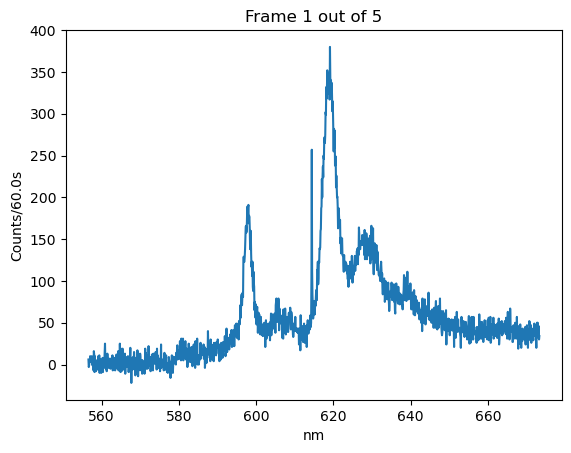

In [36]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/482_10uW_60sec_615center_300groove 2024 December 05 12_41_00.spe"
s = speFile3(filename)
frameNum = 0
s.quickPlot(frame = frameNum, ylim= None)

Transmisson room T

Successfully loaded 1 file(s) in a SpeFile object


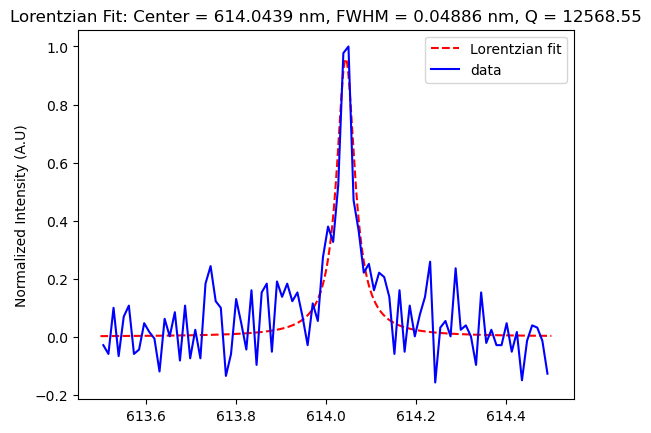

In [139]:
import pandas as pd

filename = '/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_04/482/transmission_Grating/482_10uW_300sec_615center_1800groove 2024 December 04 17_56_39.spe'
s = speFile3(filename)
frameNum = 0
# s.quickPlot(frame = frameNum, ylim= None)
# plt.xlim(613,615)
# plt.ylim(0, 1000)
# Define Lorentzian function
def lorentzian(x, x0, gamma, a):
    return a/np.pi * (gamma/2 / ((x - x0)**2 + (gamma/2)**2))

# Select data within the range 613 to 615 nm
mask = (s.wavelengths >= 613.5) & (s.wavelengths <= 614.5)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]
# Take average of first 20 points
average_first_20 = np.mean(y_data[:20])

# Subtract the average from y_data
y_data_bkg_subtracted = y_data - average_first_20
# Normalize y_data_bkg_subtracted
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))

# Fit the data to the Lorentzian function
popt, _ = curve_fit(lorentzian, x_data, y_data_normalized, p0=[614, 0.01, 1])

# Plot the fitted curve
x_fit = np.linspace(613.5, 614.5, 1000)
y_fit = lorentzian(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Lorentzian fit')
plt.plot(x_data, y_data_normalized, 'b-', label='data')
# Save the datasets into two CSV files

# Create dataframes for the datasets
df_y_data_normalized = pd.DataFrame({'x_data': x_data, 'y_data_normalized': y_data_normalized})
df_y_fit = pd.DataFrame({'x_fit': x_fit, 'y_fit': y_fit})

# Save the dataframes to CSV files
df_y_data_normalized.to_csv('y_data_normalized.csv', index=False)
df_y_fit.to_csv('y_fit.csv', index=False)
plt.ylabel('Normalized Intensity (A.U)')
plt.legend()
plt.title(f"Lorentzian Fit: Center = {popt[0]:.4f} nm, FWHM = {popt[1]:.5f} nm, Q = {popt[0]/popt[1]:.2f}")
plt.show()

Successfully loaded 1 file(s) in a SpeFile object
Center = 614.3508 nm, Gamma = 0.16222 nm, Theta = 3.50, q = 2.69, Q = 3787.07


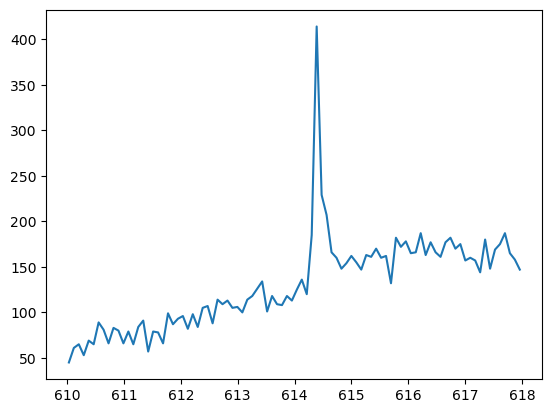

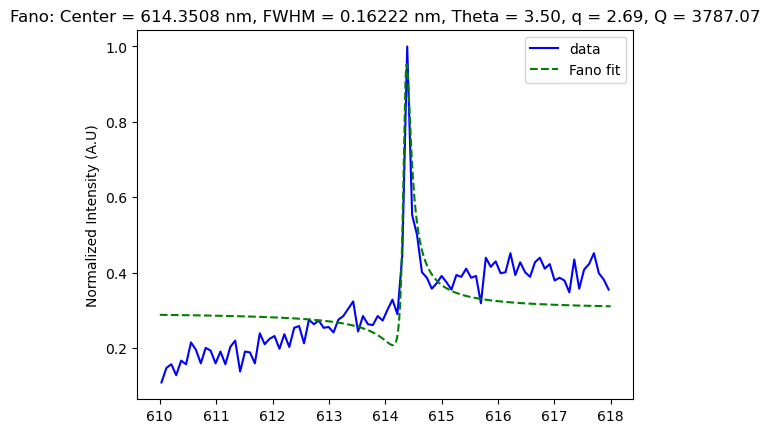

In [28]:
# 70 K data
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_70K 2024 December 05 17_07_54.spe"
s = speFile3(filename)
frameNum = 0
#s.quickPlot(frame = frameNum, ylim= None)
def lorentzian(x, x0, gamma, a):
    gamma = np.abs(gamma)
    return a/np.pi * (gamma/2 / ((x - x0)**2 + (gamma/2)**2))

def fano(x, x0, gamma, theta, B, C):
    q = 1/np.tan(theta)
    omega = 2 * (x-x0)/gamma
    D = 2*np.sin(theta)
    return D**2 * (q+omega)**2 / (1+omega**2) / B - C*x

# Select data within the range 613 to 615 nm
mask = (s.wavelengths >= 610) & (s.wavelengths <= 618)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]

# Take average of first 20 points
def bkg_computation(x_data, y_data):
    # Fit a linear line for data ranging from 612.5 to 613.5 with 614.5 to 616.5
    mask_linear = ((x_data >= 612.5) & (x_data <= 613.5)) | ((x_data >= 615.5) & (x_data <= 617.5))
    x_data_linear = x_data[mask_linear]
    y_data_linear = y_data[mask_linear]

    # Fit the data to a linear function
    def linear(x, m, c):
        return m * x + c

    popt_linear, _ = curve_fit(linear, x_data_linear, y_data_linear)
    return y_data - linear(x_data, *popt_linear)

y_data_bkg_subtracted = y_data#bkg_computation(x_data, y_data)
plt.figure()
plt.plot(x_data, y_data_bkg_subtracted)

# Normalize y_data_bkg_subtracted
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))

# Fit the data to the Lorentzian function
#popt, _ = curve_fit(lorentzian, x_data, y_data_normalized, p0=[614, 0.01, 1])
popt_fano, _ = curve_fit(fano, x_data, y_data_normalized, p0=[614.4594, .1, np.pi, 1, 1])

# Plot the fitted curve
import pandas as pd
x_fit = np.linspace(610, 618, 1000)
#y_fit = lorentzian(x_fit, *popt)
y2_fit = fano(x_fit, *popt_fano)
plt.figure()
#plt.plot(x_fit, y_fit, 'r--', label='Lorentzian fit')
plt.plot(x_data, y_data_normalized, 'b-', label='data')
df = pd.DataFrame({'x': x_data, 'y': y_data_normalized})
df.to_csv('fano_data.csv')
plt.plot(x_fit, y2_fit, 'g--', label=f'Fano fit')
df2 = pd.DataFrame({'x': x_fit, 'y': y2_fit})
df2.to_csv('fano_fit.csv')
print(f"Center = {popt_fano[0]:.4f} nm, Gamma = {popt_fano[1]:.5f} nm, Theta = {popt_fano[2]:.2f}, q = {1/np.tan(popt_fano[2]):.2f}, Q = {popt_fano[0]/popt_fano[1]:.2f}")
plt.ylabel('Normalized Intensity (A.U)')
plt.legend()
plt.title(f"Fano: Center = {popt_fano[0]:.4f} nm, FWHM = {popt_fano[1]:.5f} nm, Theta = {popt_fano[2]:.2f}, q = {1/np.tan(popt_fano[2]):.2f}, Q = {popt_fano[0]/popt_fano[1]:.2f}")
plt.show()

Grating analysis at 1800 for cavity

Successfully loaded 1 file(s) in a SpeFile object
Center = 614.0461 nm, Gamma = 0.04336 nm, Theta = 3.40, q = 3.77, Q = 14162.26


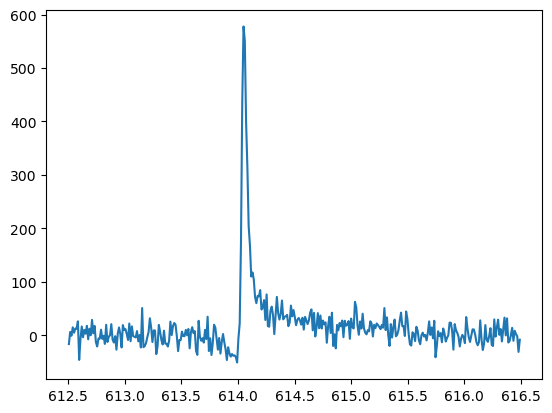

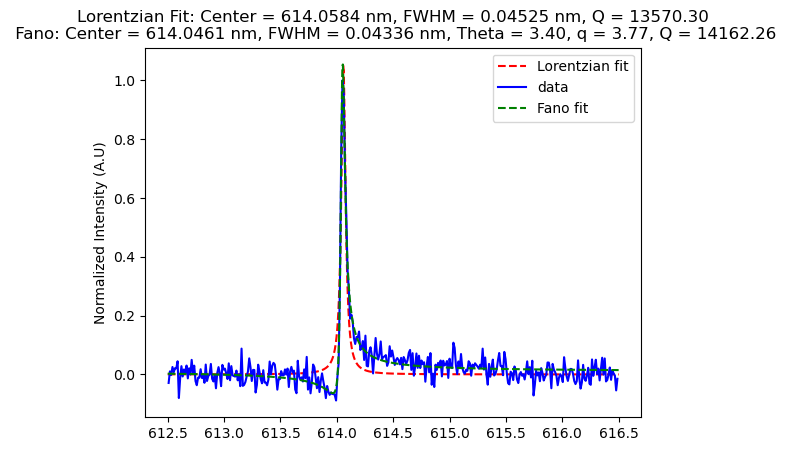

In [138]:
filename = '/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_04/482/slit_closed/482_10uW_300sec_615center_1800groove 2024 December 04 16_39_51.spe'
s = speFile3(filename)
frameNum = 0
#s.quickPlot(frame = frameNum, ylim= None)
def lorentzian(x, x0, gamma, a):
    gamma = np.abs(gamma)
    return a/np.pi * (gamma/2 / ((x - x0)**2 + (gamma/2)**2))

def fano(x, x0, gamma, theta, B, C):
    q = 1/np.tan(theta)
    omega = 2 * (x-x0)/gamma
    D = 2*np.sin(theta)
    return D**2 * (q+omega)**2 / (1+omega**2) / B - C*x

# Select data within the range 613 to 615 nm
mask = (s.wavelengths >= 612.5) & (s.wavelengths <= 616.5)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]

# Take average of first 20 points
def bkg_computation(x_data, y_data):
    # Fit a linear line for data ranging from 612.5 to 613.5 with 614.5 to 616.5
    mask_linear = ((x_data >= 612.5) & (x_data <= 613.5)) | ((x_data >= 615.5) & (x_data <= 617.5))
    x_data_linear = x_data[mask_linear]
    y_data_linear = y_data[mask_linear]

    # Fit the data to a linear function
    def linear(x, m, c):
        return m * x + c

    popt_linear, _ = curve_fit(linear, x_data_linear, y_data_linear)
    return y_data - linear(x_data, *popt_linear)

y_data_bkg_subtracted = bkg_computation(x_data, y_data)
plt.figure()
plt.plot(x_data, y_data_bkg_subtracted)

# Normalize y_data_bkg_subtracted
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))

# Fit the data to the Lorentzian function
popt, _ = curve_fit(lorentzian, x_data, y_data_normalized, p0=[614, 0.01, 1])
popt_fano, _ = curve_fit(fano, x_data, y_data_normalized, p0=[614.0594, .01, np.pi, 1, 1])

# Plot the fitted curve
import pandas as pd
x_fit = np.linspace(612.5, 616.5, 1000)
y_fit = lorentzian(x_fit, *popt)
y2_fit = fano(x_fit, *popt_fano)
plt.figure()
plt.plot(x_fit, y_fit, 'r--', label='Lorentzian fit')
plt.plot(x_data, y_data_normalized, 'b-', label='data')
df = pd.DataFrame({'x': x_data, 'y': y_data_normalized})
df.to_csv('fano_data.csv')
plt.plot(x_fit, y2_fit, 'g--', label=f'Fano fit')
df2 = pd.DataFrame({'x': x_fit, 'y': y2_fit})
df2.to_csv('fano_fit.csv')
print(f"Center = {popt_fano[0]:.4f} nm, Gamma = {popt_fano[1]:.5f} nm, Theta = {popt_fano[2]:.2f}, q = {1/np.tan(popt_fano[2]):.2f}, Q = {popt_fano[0]/popt_fano[1]:.2f}")
plt.ylabel('Normalized Intensity (A.U)')
plt.legend()
plt.title(f"Lorentzian Fit: Center = {popt[0]:.4f} nm, FWHM = {popt[1]:.5f} nm, Q = {popt[0]/popt[1]:.2f}\n Fano: Center = {popt_fano[0]:.4f} nm, FWHM = {popt_fano[1]:.5f} nm, Theta = {popt_fano[2]:.2f}, q = {1/np.tan(popt_fano[2]):.2f}, Q = {popt_fano[0]/popt_fano[1]:.2f}")
plt.show()


Broad 300g/mm grating spectra

Successfully loaded 1 file(s) in a SpeFile object


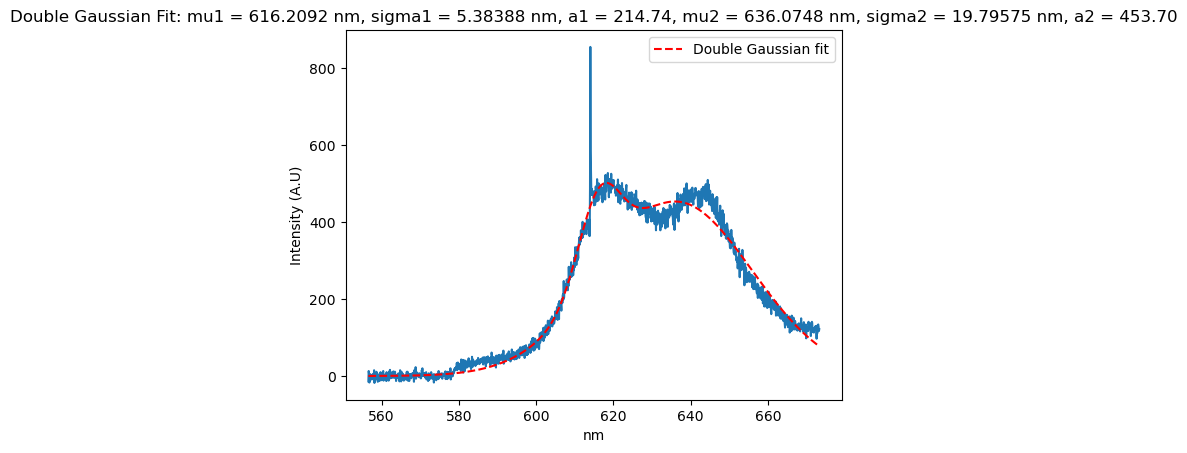

In [5]:
filename = '/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_04/482/slit_closed/482_10uW_60sec_615center 2024 December 04 16_10_06.spe'
s = speFile3(filename)
frameNum = 0
s.quickPlot(frame = frameNum, ylim= None)
# Define a function for the sum of two Gaussians
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]
def double_gaussian(x, mu1, sigma1, a1, mu2, sigma2, a2):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))

# Fit the data to the double Gaussian function
popt, _ = curve_fit(double_gaussian, x_data, y_data, p0=[620, 20, 500, 650, 20, 500])

# Plot the fitted curve
y_fit = double_gaussian(s.wavelengths, *popt)
plt.plot(s.wavelengths, y_fit, 'r--', label='Double Gaussian fit')
#plt.xlim([630,660])
#plt.plot(x_data, y_data, 'b-', label='data')
plt.ylabel('Intensity (A.U)')
plt.legend()
plt.title(f"Double Gaussian Fit: mu1 = {popt[0]:.4f} nm, sigma1 = {popt[1]:.5f} nm, a1 = {popt[2]:.2f}, mu2 = {popt[3]:.4f} nm, sigma2 = {popt[4]:.5f} nm, a2 = {popt[5]:.2f}")
plt.show()

Successfully loaded 1 file(s) in a SpeFile object


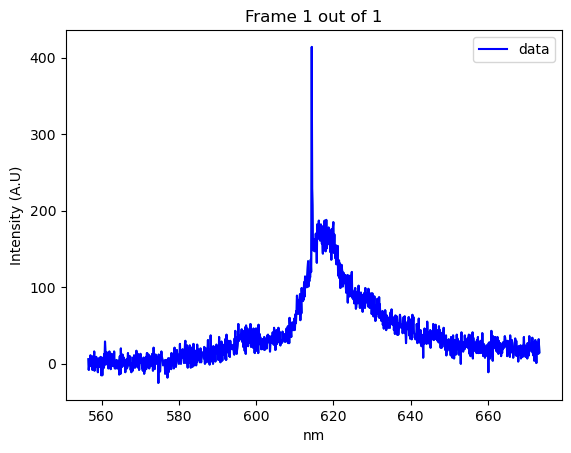

In [31]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_70K 2024 December 05 17_07_54.spe"
s = speFile3(filename)
frameNum = 0
s.quickPlot(frame = frameNum, ylim= None)
# Define a function for the sum of two Gaussians
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]
# Save x_data and y_data to a CSV file
df_70K = pd.DataFrame({'Wavelength (nm)': x_data, 'Intensity (counts/s)': y_data})
df_70K.to_csv('70K_data.csv', index=False)
#plt.xlim([630,660])
plt.plot(x_data, y_data, 'b-', label='data')
plt.ylabel('Intensity (A.U)')
plt.legend()
plt.show()